In [1]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [2]:
OPTIONS = json.loads(open('../../info.json', 'r', encoding='utf-8').read())
OPTIONS

{'test': 1}

In [3]:
TEST_NUM = OPTIONS['test']
PATH     = f'../files/test{TEST_NUM}'
PATH

'../files/test1'

In [4]:
TARGET_VAR  = 'pitch'
LIMITS      = json.loads(open(os.path.join(PATH, 'info.json'), 'r').read()).get('limits')
STATIC_LIMITS  = LIMITS.get('static')
DYNAMIC_LIMITS = LIMITS.get('dynamic')

print(LIMITS)
print(STATIC_LIMITS)
print(DYNAMIC_LIMITS)

{'dynamic': [15, 600], 'static': [700, 999999999]}
[700, 999999999]
[15, 600]


# IMPORTANDO DADOS

In [5]:
df = pd.read_csv(f'{PATH}/reference/data.csv')
df['time']   = (df.time - df.time.values[0])
df['static'] = (df.time > STATIC_LIMITS[0])
df

,ay,q3,roll,la_pos_mon_d,q0,wx,pitch,time,wz,yaw,q2,wy,ax,q1,az,sample_time,static
0,-9.785,0.000020,0.000095,0.000000,1.0000,0.000064,0.000042,0.000000,0.000066,0.000038,0.000023,-0.000021,-0.03326,0.000048,-0.2374,905000000.0,False
1,-9.785,0.000023,0.000092,0.000000,1.0000,-0.000107,0.000050,0.064848,0.000044,0.000046,0.000026,0.000030,-0.03321,0.000046,-0.2375,5000000.0,False
2,-9.785,0.000023,0.000099,0.000000,1.0000,0.000084,0.000050,0.168181,0.000074,0.000042,0.000027,-0.000057,-0.03332,0.000051,-0.2376,105000000.0,False
3,-9.785,0.000027,0.000114,0.000000,1.0000,0.000030,0.000057,0.269503,-0.000007,0.000053,0.000029,0.000114,-0.03304,0.000059,-0.2372,205000000.0,False
4,-9.786,0.000035,0.000107,0.000000,1.0000,0.000067,0.000069,0.368434,0.000121,0.000069,0.000036,0.000339,-0.03332,0.000055,-0.2376,305000000.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431977,-9.787,-0.019310,1.547000,-0.001526,-0.7152,0.000150,-0.006973,43199.403495,-0.000074,0.047170,-0.013980,0.000100,-0.02457,-0.698600,-0.2317,605000000.0,True
431978,-9.787,-0.019310,1.547000,-0.001464,-0.7152,0.000007,-0.006977,43199.512243,0.000073,0.047180,-0.013980,0.000185,-0.02456,-0.698600,-0.2316,705000000.0,True
431979,-9.787,-0.019310,1.547000,-0.001401,-0.7152,-0.000046,-0.006977,43199.609807,0.000147,0.047170,-0.013980,-0.000047,-0.02454,-0.698600,-0.2317,805000000.0,True
431980,-9.787,-0.019310,1.547000,-0.001338,-0.7152,-0.000079,-0.006981,43199.704816,0.000175,0.047180,-0.013980,-0.000013,-0.02457,-0.698600,-0.2318,905000000.0,True


- Convertendo pra radianos

In [6]:
for col in ['wx', 'wy', 'wz', 'pitch', 'roll', 'yaw']:
    df.loc[:, col] = df[col] * 180.00/np.pi

df

,ay,q3,roll,la_pos_mon_d,q0,wx,pitch,time,wz,yaw,q2,wy,ax,q1,az,sample_time,static
0,-9.785,0.000020,0.005463,0.000000,1.0000,0.003687,0.002404,0.000000,0.003762,0.002185,0.000023,-0.001227,-0.03326,0.000048,-0.2374,905000000.0,False
1,-9.785,0.000023,0.005244,0.000000,1.0000,-0.006148,0.002841,0.064848,0.002540,0.002622,0.000026,0.001723,-0.03321,0.000046,-0.2375,5000000.0,False
2,-9.785,0.000023,0.005681,0.000000,1.0000,0.004803,0.002841,0.168181,0.004215,0.002404,0.000027,-0.003276,-0.03332,0.000051,-0.2376,105000000.0,False
3,-9.785,0.000027,0.006555,0.000000,1.0000,0.001734,0.003278,0.269503,-0.000422,0.003059,0.000029,0.006520,-0.03304,0.000059,-0.2372,205000000.0,False
4,-9.786,0.000035,0.006119,0.000000,1.0000,0.003831,0.003933,0.368434,0.006944,0.003933,0.000036,0.019418,-0.03332,0.000055,-0.2376,305000000.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431977,-9.787,-0.019310,88.636571,-0.001526,-0.7152,0.008594,-0.399523,43199.403495,-0.004258,2.702642,-0.013980,0.005747,-0.02457,-0.698600,-0.2317,605000000.0,True
431978,-9.787,-0.019310,88.636571,-0.001464,-0.7152,0.000384,-0.399753,43199.512243,0.004178,2.703215,-0.013980,0.010600,-0.02456,-0.698600,-0.2316,705000000.0,True
431979,-9.787,-0.019310,88.636571,-0.001401,-0.7152,-0.002646,-0.399753,43199.609807,0.008434,2.702642,-0.013980,-0.002668,-0.02454,-0.698600,-0.2317,805000000.0,True
431980,-9.787,-0.019310,88.636571,-0.001338,-0.7152,-0.004552,-0.399982,43199.704816,0.010015,2.703215,-0.013980,-0.000747,-0.02457,-0.698600,-0.2318,905000000.0,True


In [7]:
removed = df[df.duplicated(subset=['time'], keep='first')]
df      = df.drop_duplicates(subset=['time'], keep='first')
removed

,ay,q3,roll,la_pos_mon_d,q0,wx,pitch,time,wz,yaw,q2,wy,ax,q1,az,sample_time,static


# VISUALIZAÇÃO DE VARIÁVEIS

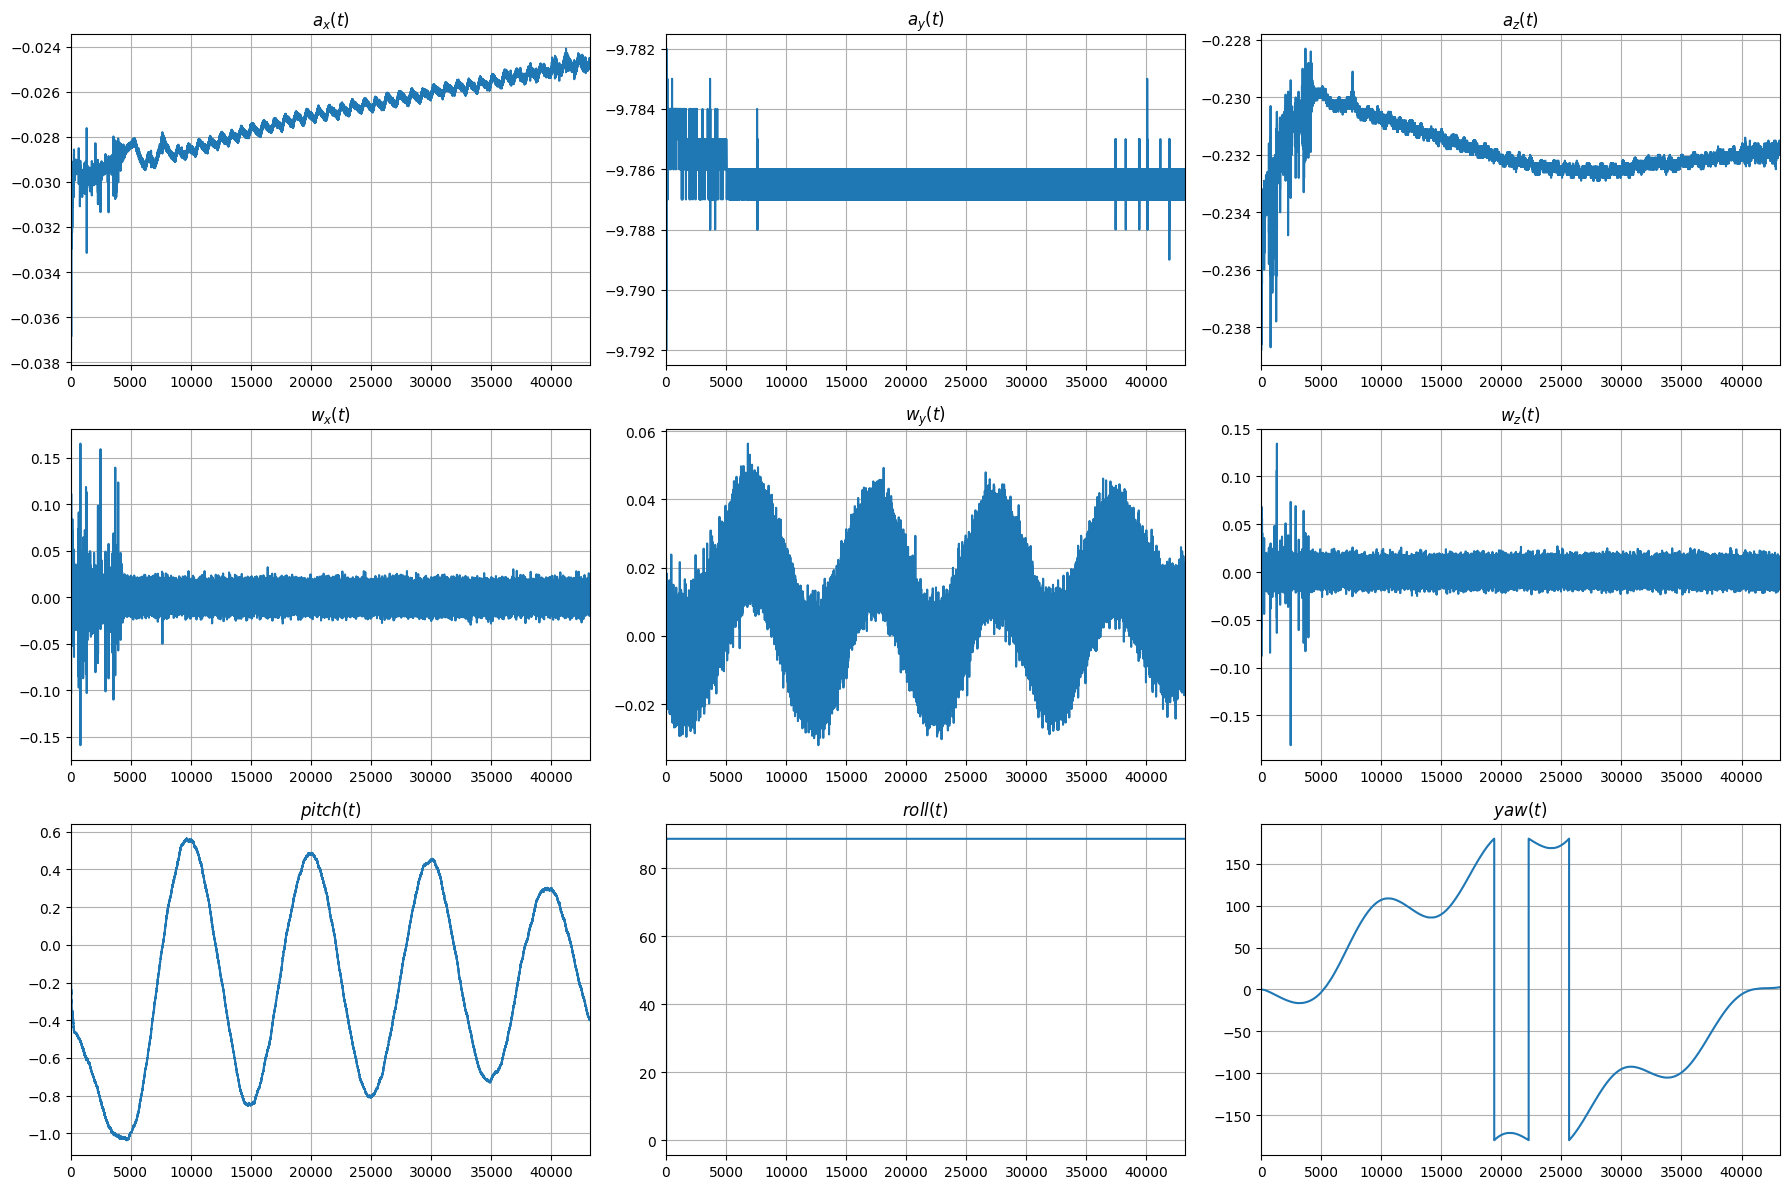

In [8]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

# AMOSTRAGEM

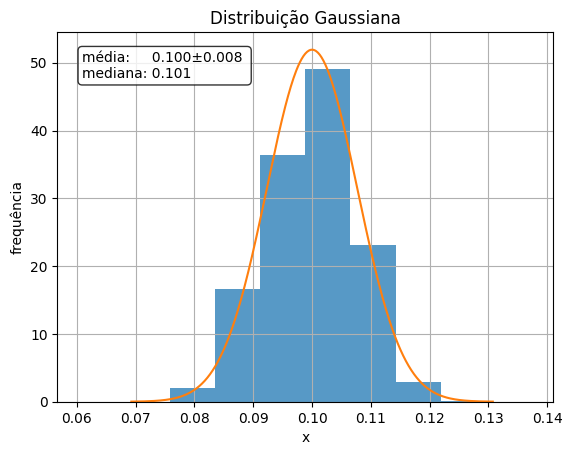

In [9]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
dt = 0.10
gaussian(time)

In [10]:
def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


df = normalizePeriod(df, 'time', dt)
df

,time,ay,q3,roll,la_pos_mon_d,q0,wx,pitch,wz,yaw,q2,wy,ax,q1,az,sample_time,static
0,0.0,-9.785,0.000020,0.005463,0.000000,1.0000,0.003687,0.002404,0.003762,0.002185,0.000023,-0.001227,-0.03326,0.000048,-0.2374,905000000.0,False
1,0.1,-9.785,0.000023,0.005244,0.000000,1.0000,-0.006148,0.002841,0.002540,0.002622,0.000026,0.001723,-0.03321,0.000046,-0.2375,5000000.0,False
2,0.2,-9.785,0.000023,0.005681,0.000000,1.0000,0.004803,0.002841,0.004215,0.002404,0.000027,-0.003276,-0.03332,0.000051,-0.2376,105000000.0,False
3,0.3,-9.785,0.000027,0.006555,0.000000,1.0000,0.001734,0.003278,-0.000422,0.003059,0.000029,0.006520,-0.03304,0.000059,-0.2372,205000000.0,False
4,0.4,-9.786,0.000035,0.006119,0.000000,1.0000,0.003831,0.003933,0.006944,0.003933,0.000036,0.019418,-0.03332,0.000055,-0.2376,305000000.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431994,43199.4,-9.787,-0.019310,88.636571,-0.001588,-0.7152,0.000811,-0.399753,0.004295,2.702069,-0.013980,0.005850,-0.02464,-0.698600,-0.2317,505000000.0,True
431995,43199.5,-9.787,-0.019310,88.636571,-0.001526,-0.7152,0.008594,-0.399523,-0.004258,2.702642,-0.013980,0.005747,-0.02457,-0.698600,-0.2317,605000000.0,True
431996,43199.6,-9.787,-0.019310,88.636571,-0.001464,-0.7152,0.000384,-0.399753,0.004178,2.703215,-0.013980,0.010600,-0.02456,-0.698600,-0.2316,705000000.0,True
431997,43199.7,-9.787,-0.019310,88.636571,-0.001401,-0.7152,-0.002646,-0.399753,0.008434,2.702642,-0.013980,-0.002668,-0.02454,-0.698600,-0.2317,805000000.0,True


# FILTRANDO POR VARIAVEL

In [11]:
df = df.loc[(df.time >= DYNAMIC_LIMITS[0]) & (df.time <= STATIC_LIMITS[1])]
df.loc[:, 'time'] = (df.time - df.time.values[0])

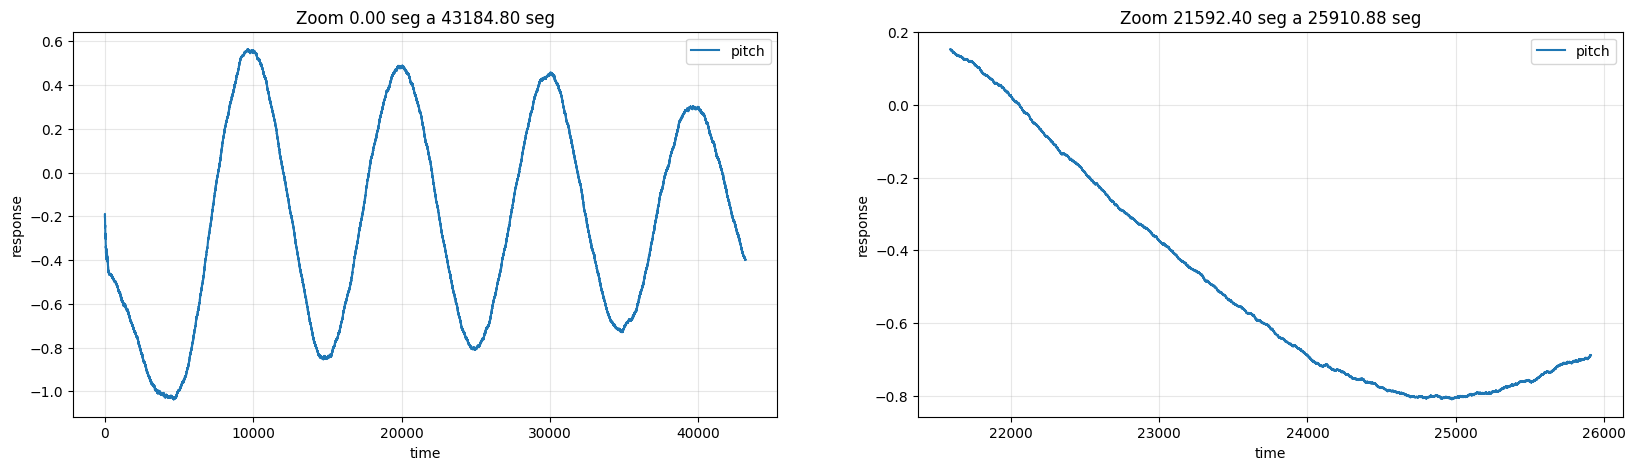

In [12]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df, limits=(0.5, 0.6))

# SALVANDO DADOS

In [13]:
df = df.rename(columns={col: 'ref_' + col for col in df.columns if col not in ['time', 'static']})
df

,time,ref_ay,ref_q3,ref_roll,ref_la_pos_mon_d,ref_q0,ref_wx,ref_pitch,ref_wz,ref_yaw,ref_q2,ref_wy,ref_ax,ref_q1,ref_az,ref_sample_time,static
150,0.0,-9.785,0.001270,88.636571,-0.004591,0.7156,0.006102,-0.202598,-0.004200,0.005244,-0.001234,0.013986,-0.03410,0.6985,-0.2369,905000000.0,False
151,0.1,-9.788,0.001261,88.636571,-0.005488,0.7156,-0.000854,-0.201280,-0.028648,0.005244,-0.001224,-0.000304,-0.03523,0.6986,-0.2365,5000000.0,False
152,0.2,-9.787,0.001229,88.636571,-0.006479,0.7156,0.009987,-0.196238,-0.059645,0.005026,-0.001196,-0.011900,-0.03484,0.6986,-0.2365,105000000.0,False
153,0.3,-9.785,0.001195,88.636571,-0.007552,0.7155,0.028877,-0.190566,-0.045573,0.005026,-0.001159,0.006652,-0.03261,0.6986,-0.2369,205000000.0,False
154,0.4,-9.782,0.001188,88.636571,-0.008666,0.7155,-0.000833,-0.189477,0.007231,0.005026,-0.001153,-0.001580,-0.03051,0.6986,-0.2359,305000000.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431994,43184.4,-9.787,-0.019310,88.636571,-0.001588,-0.7152,0.000811,-0.399753,0.004295,2.702069,-0.013980,0.005850,-0.02464,-0.6986,-0.2317,505000000.0,True
431995,43184.5,-9.787,-0.019310,88.636571,-0.001526,-0.7152,0.008594,-0.399523,-0.004258,2.702642,-0.013980,0.005747,-0.02457,-0.6986,-0.2317,605000000.0,True
431996,43184.6,-9.787,-0.019310,88.636571,-0.001464,-0.7152,0.000384,-0.399753,0.004178,2.703215,-0.013980,0.010600,-0.02456,-0.6986,-0.2316,705000000.0,True
431997,43184.7,-9.787,-0.019310,88.636571,-0.001401,-0.7152,-0.002646,-0.399753,0.008434,2.702642,-0.013980,-0.002668,-0.02454,-0.6986,-0.2317,805000000.0,True


In [14]:
os.makedirs('output', exist_ok=True)
df.to_csv('output/data.csv', index=None)